# Ejercicio 8 - Incorporacion de 2025 y analisis 2024-2026

Consultas en `sql/07_ejercicio_8.sql`; documentacion generada en
`docs/ejercicio_8_resultados.md` por `scripts/run_ejercicio_8.py`.

## 8.1 Cambio al sistema de descarga

Solo fue necesario agregar 2025 a los anios predeterminados de
`scripts/download_data.py`:

```python
ANIOS_PREDETERMINADOS = (2024, 2025, 2026)
```

## 8.2 Los archivos existentes no se descargan de nuevo

La primera ejecucion descargo 24 archivos (2025) y omitio 40 (2024 y 2026). La
siguiente celda vuelve a ejecutar el descargador: todos los archivos deben aparecer
como existentes.

In [1]:
import lab_utils
!python scripts/download_data.py | tail -9

RESUMEN
  descargados   : 0
  ya existian   : 64
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0


In [2]:
from lab_utils import BASE_INDICADORES, conectar, ejecutar, tablero
import matplotlib.pyplot as plt

# Conexion en memoria (lee Parquet) con la base de indicadores adjunta como `taxi`.
con = conectar()
con.execute(f"ATTACH '{BASE_INDICADORES}' AS taxi (READ_ONLY)")

ejecutar(con, "07_ejercicio_8.sql", "01_cobertura")

**Cobertura de archivos por anio y tipo** (`07_ejercicio_8.sql` - `01_cobertura`)

- **Objetivo:** Verificar que existen los doce meses de 2024 y 2025 y los meses publicados de 2026 para ambos servicios (8.1, 8.2).
- **Fuente:** glob sobre data/raw/*/*/*.parquet
- **Decision:** Se esperan 12, 12 y 8 archivos por tipo; septiembre a diciembre de 2026 aun no estaban publicados.

```sql
WITH archivos AS (
    SELECT regexp_extract(file, '(yellow|green)', 1) AS tipo_taxi,
           CAST(regexp_extract(file, 'tripdata_(\d{4})-', 1) AS INTEGER) AS anio,
           CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS mes
    FROM glob('data/raw/*/*/*.parquet')
)
SELECT anio, tipo_taxi, count(*) AS archivos, min(mes) AS primer_mes, max(mes) AS ultimo_mes
FROM archivos
GROUP BY ALL
ORDER BY anio, tipo_taxi;
```

,anio,tipo_taxi,archivos,primer_mes,ultimo_mes
0,2024,green,12,1,12
1,2024,yellow,12,1,12
2,2025,green,12,1,12
3,2025,yellow,12,1,12
4,2026,green,8,1,8
5,2026,yellow,8,1,8


## 8.3 Las consultas siguen funcionando con el conjunto ampliado

Los notebooks `01` a `07` se volvieron a ejecutar sin cambios y terminaron sin
errores. Las siguientes consultas comprueban que la lectura directa de Parquet abarca
los tres anios, que la tabla materializada tiene exactamente los mismos registros y
que los cambios de esquema entre anios no rompen el flujo.

In [3]:
ejecutar(con, "07_ejercicio_8.sql", "02_parquet_vs_tabla")

**Registros en Parquet y en la tabla materializada** (`07_ejercicio_8.sql` - `02_parquet_vs_tabla`)

- **Objetivo:** Comprobar que la consulta directa sobre los tres anios funciona y que la tabla `viajes` contiene exactamente los mismos registros (8.3).
- **Fuente:** data/raw/*/*/*.parquet y taxi.viajes
- **Decision:** Una diferencia distinta de cero indicaria que la base de indicadores no se reconstruyo despues de descargar 2025.

```sql
WITH parquet AS (
    SELECT CAST(regexp_extract(filename, 'tripdata_(\d{4})-', 1) AS INTEGER) AS anio,
           CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END AS tipo_taxi,
           count(*) AS registros_parquet
    FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
    GROUP BY ALL
), tabla AS (
    SELECT anio, tipo_taxi, count(*) AS registros_tabla
    FROM taxi.viajes
    GROUP BY ALL
)
SELECT anio, tipo_taxi, registros_parquet, registros_tabla,
       registros_parquet - registros_tabla AS diferencia
FROM parquet FULL JOIN tabla USING (anio, tipo_taxi)
ORDER BY anio, tipo_taxi;
```

,anio,tipo_taxi,registros_parquet,registros_tabla,diferencia
0,2024,green,660218,660218,0
1,2024,yellow,41169720,41169720,0
2,2025,green,591375,591375,0
3,2025,yellow,48722602,48722602,0
4,2026,green,337114,337114,0
5,2026,yellow,29703355,29703355,0


In [4]:
ejecutar(con, "07_ejercicio_8.sql", "03_cambios_esquema")

**Columnas que no estan presentes en todos los anios** (`07_ejercicio_8.sql` - `03_cambios_esquema`)

- **Objetivo:** Identificar cambios de esquema entre anios que podrian romper consultas que asumen columnas fijas (8.3).
- **Fuente:** parquet_schema sobre data/raw/*/*/*.parquet
- **Decision:** Las consultas usan union_by_name, que completa con NULL las columnas ausentes; por eso estos cambios no rompen el flujo, pero hay que tenerlos en cuenta al interpretar.

```sql
WITH columnas AS (
    SELECT regexp_extract(file_name, '(yellow|green)', 1) AS tipo_taxi,
           regexp_extract(file_name, 'tripdata_(\d{4}-\d{2})', 1) AS periodo,
           name AS columna
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE name <> 'schema'
), totales AS (
    SELECT tipo_taxi, count(DISTINCT periodo) AS archivos_tipo FROM columnas GROUP BY tipo_taxi
)
SELECT c.tipo_taxi, c.columna,
       count(DISTINCT c.periodo) AS archivos_con_columna,
       t.archivos_tipo,
       min(c.periodo) AS desde,
       max(c.periodo) AS hasta
FROM columnas AS c
JOIN totales AS t USING (tipo_taxi)
GROUP BY c.tipo_taxi, c.columna, t.archivos_tipo
HAVING count(DISTINCT c.periodo) < t.archivos_tipo
ORDER BY c.tipo_taxi, desde, c.columna;
```

,tipo_taxi,columna,archivos_con_columna,archivos_tipo,desde,hasta
0,green,cbd_congestion_fee,20,32,2025-01,2026-08
1,green,request_source,3,32,2026-06,2026-08
2,yellow,cbd_congestion_fee,20,32,2025-01,2026-08
3,yellow,request_source,3,32,2026-06,2026-08


Solo dos columnas no existen en todos los archivos: `cbd_congestion_fee` (desde enero de
2025) y `request_source` (desde junio de 2026). Como las consultas usan
`union_by_name`, en los archivos donde faltan se leen como `NULL`.

## 8.4 Indicadores y visualizaciones con los tres anios

Los diez indicadores del Ejercicio 7 se recalculan sobre la base reconstruida sin
modificar su SQL. El tablero de Metabase se actualiza con
`scripts/setup_metabase.py`.

In [5]:
from lab_utils import SQL_INDICADORES, consultas

# Las consultas de indicadores usan `viajes` sin prefijo: se resuelven en `taxi`.
con.execute("USE taxi")
indicadores = {n: ejecutar(con, SQL_INDICADORES, n, mostrar_sql=False)
               for n in consultas(SQL_INDICADORES)}

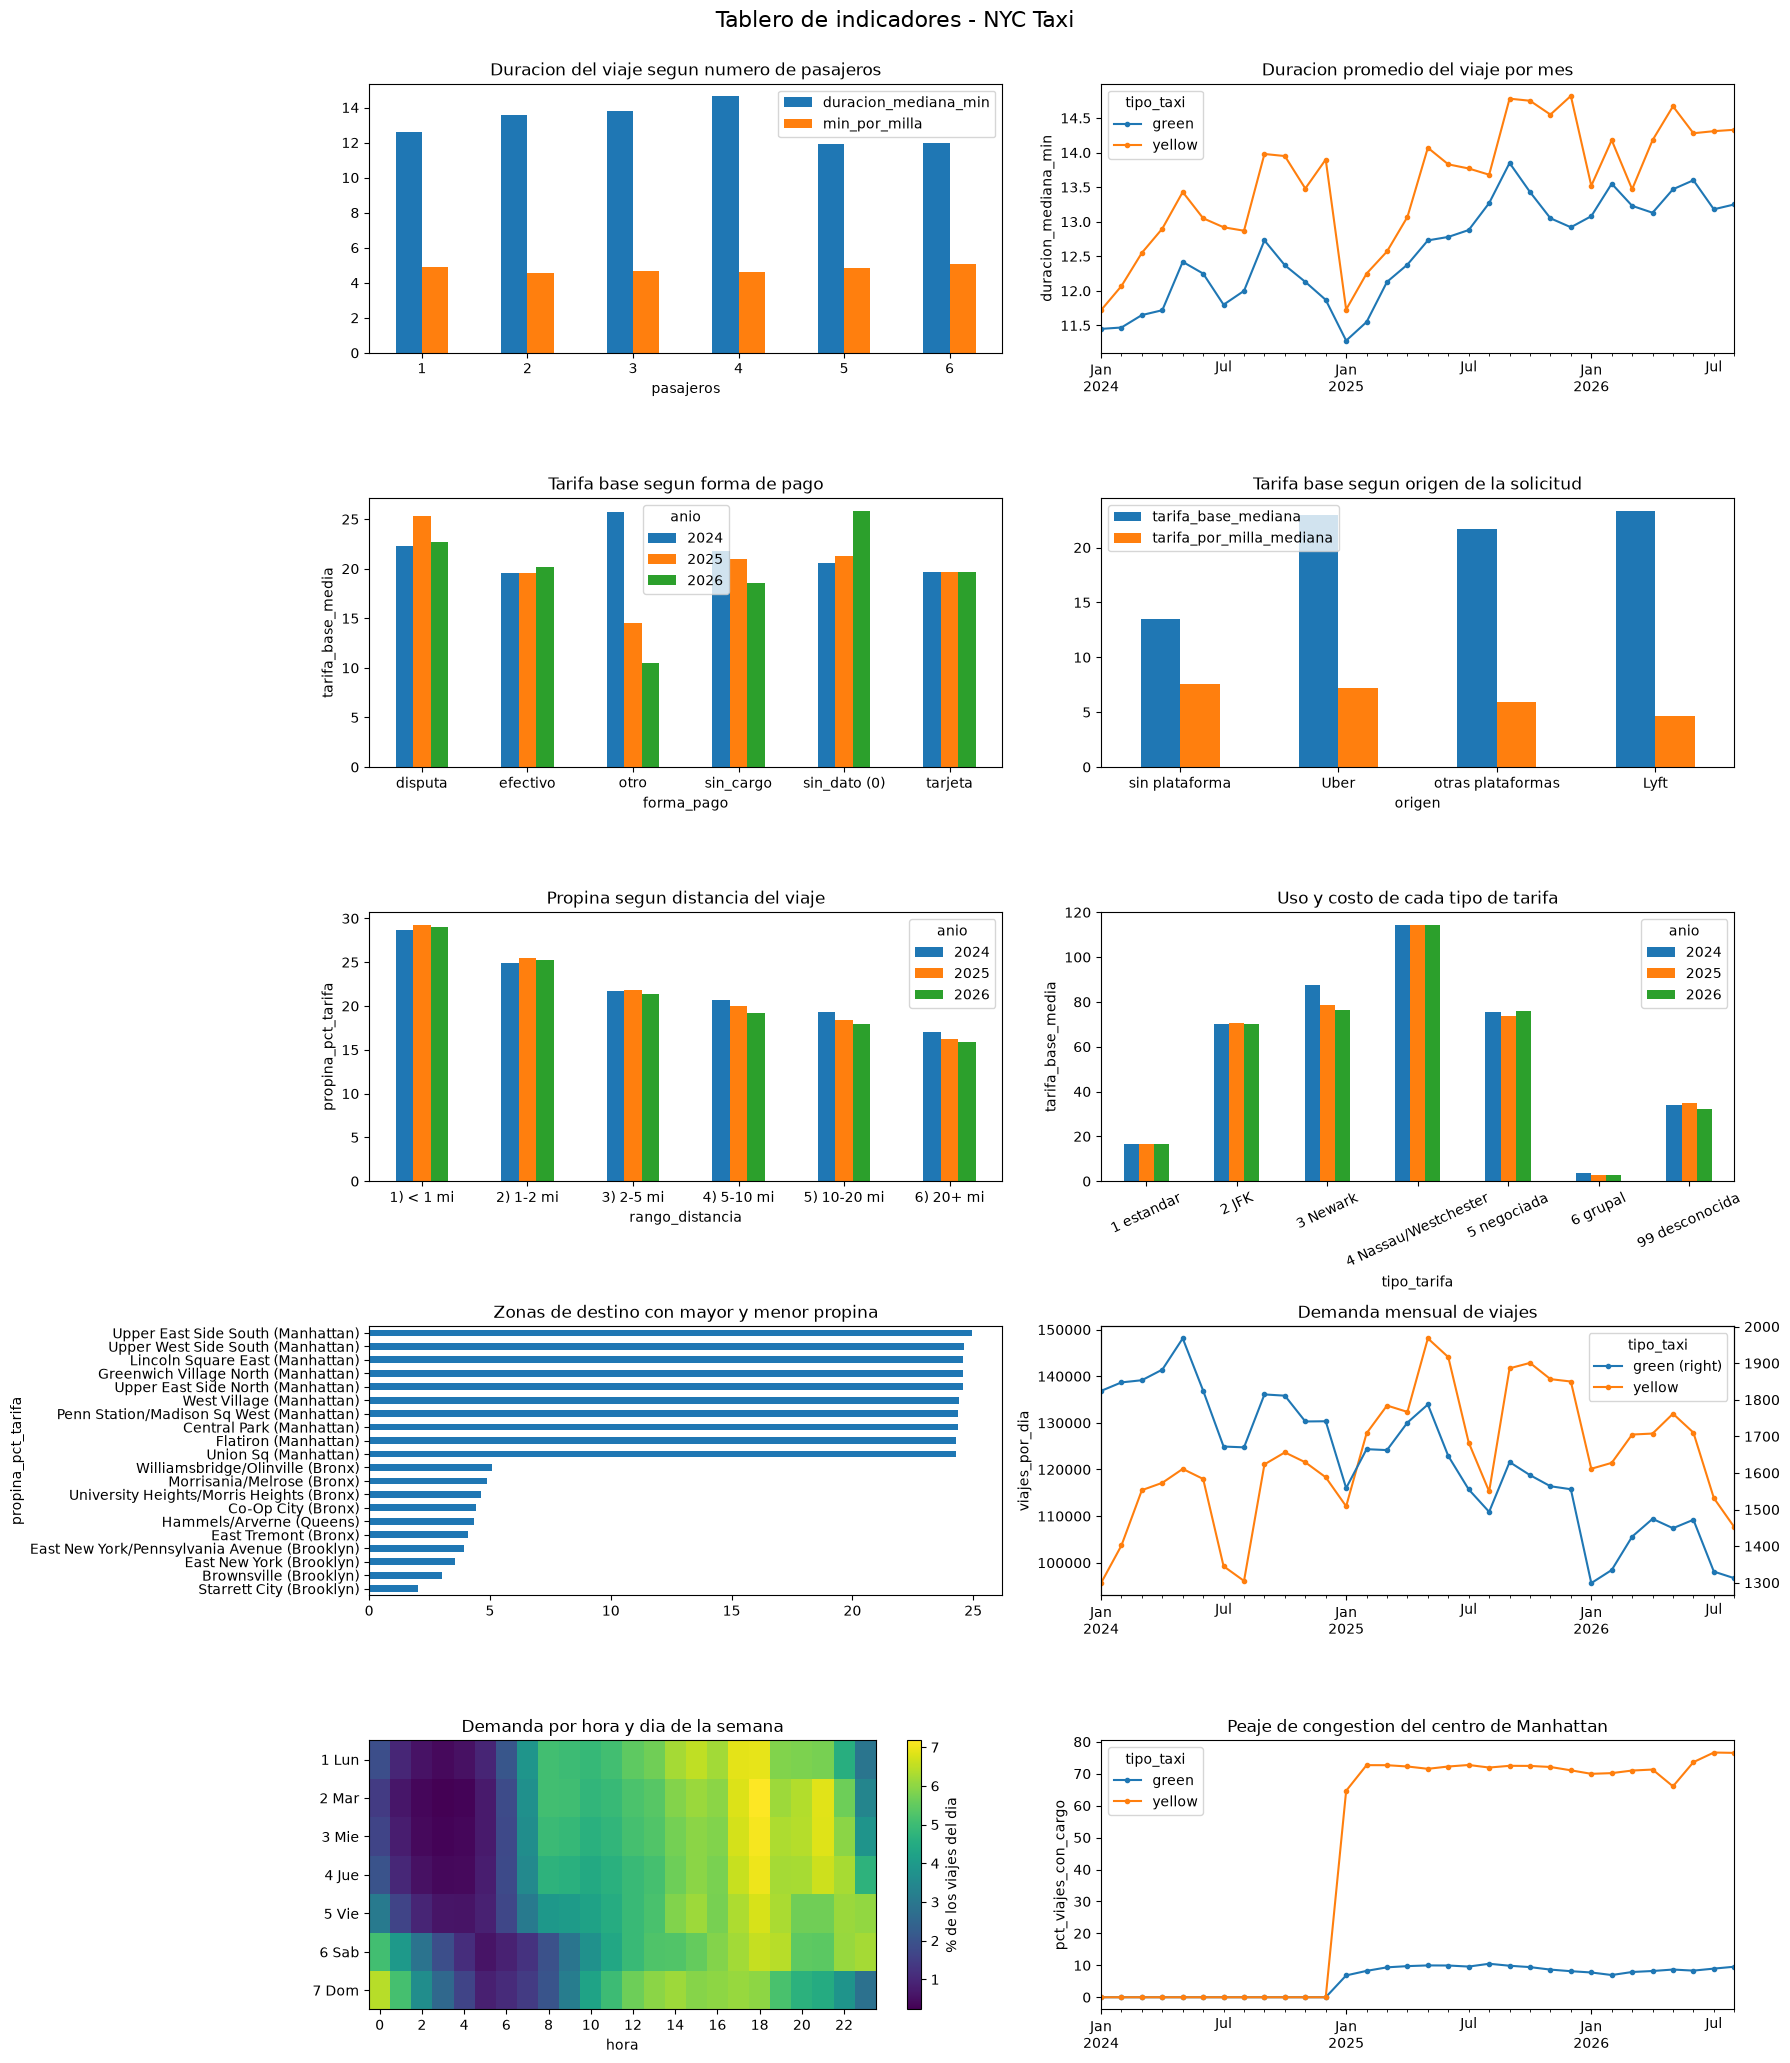

In [6]:
tablero(indicadores);

## 8.5 Evolucion de los indicadores en un periodo comparable

2026 solo tiene enero a agosto, asi que la comparacion anual se restringe a esos meses.

In [7]:
anual = ejecutar(con, "07_ejercicio_8.sql", "04_comparacion_enero_agosto")
anual

**Evolucion anual en un periodo comparable (enero a agosto)** (`07_ejercicio_8.sql` - `04_comparacion_enero_agosto`)

- **Objetivo:** Comparar los tres anios con los mismos meses, porque 2026 solo tiene enero a agosto (8.5).
- **Fuente:** taxi.viajes y taxi.viajes_validos
- **Decision:** Comparar anios completos contra un anio parcial exageraria la caida de 2026; por eso se restringe a enero-agosto.

```sql
WITH base AS (
    SELECT anio, tipo_taxi,
           count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)) AS viajes_por_dia,
           round(100.0 * avg(CASE WHEN cbd_congestion_fee > 0 THEN 1 ELSE 0 END), 2) AS pct_con_peaje
    FROM taxi.viajes
    WHERE mes <= 8 AND year(pickup_datetime) = anio
    GROUP BY ALL
), validos AS (
    SELECT anio, tipo_taxi,
           round(median(duracion_min), 2) AS duracion_mediana_min,
           round(median(trip_distance), 2) AS distancia_mediana,
           round(median(fare_amount), 2) AS tarifa_base_mediana,
           round(100.0 * avg(CASE WHEN payment_type = 1 THEN 1 ELSE 0 END), 2) AS pct_tarjeta,
           round(100.0 * avg(CASE WHEN tip_amount > 0 THEN 1 ELSE 0 END)
                 FILTER (WHERE payment_type = 1), 2) AS pct_tarjeta_con_propina
    FROM taxi.viajes_validos
    WHERE mes <= 8
    GROUP BY ALL
)
SELECT anio, tipo_taxi, round(viajes_por_dia, 0) AS viajes_por_dia,
       duracion_mediana_min, distancia_mediana, tarifa_base_mediana,
       pct_tarjeta, pct_tarjeta_con_propina, pct_con_peaje
FROM base JOIN validos USING (anio, tipo_taxi)
ORDER BY tipo_taxi DESC, anio;
```

,anio,tipo_taxi,viajes_por_dia,duracion_mediana_min,distancia_mediana,tarifa_base_mediana,pct_tarjeta,pct_tarjeta_con_propina,pct_con_peaje
0,2024,yellow,107269,12.70,1.80,13.50,75.70,94.45,0.00
1,2025,yellow,129330,13.12,1.90,13.50,66.16,93.39,71.43
2,2026,yellow,122236,14.10,1.93,15.60,65.36,91.13,71.76
3,2024,green,1810,11.85,1.96,13.50,67.73,91.24,0.00
4,2025,green,1631,12.37,2.02,13.50,69.51,91.14,9.30
5,2026,green,1387,13.32,2.15,13.50,65.51,91.39,8.32


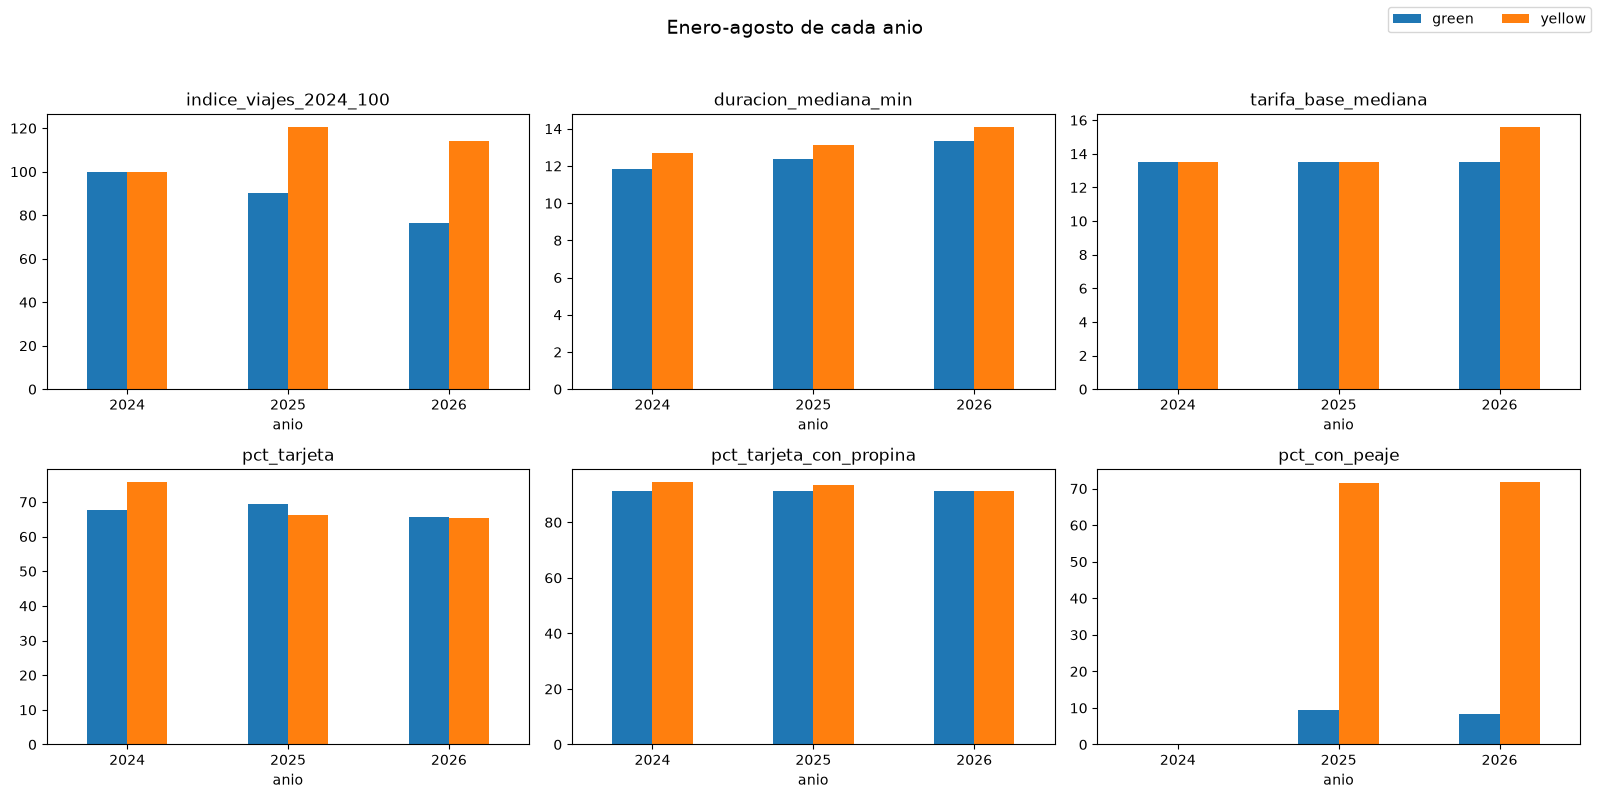

In [8]:
# Indice 2024 = 100 para comparar el crecimiento de servicios de escala muy distinta.
anual["indice_viajes_2024_100"] = (100 * anual.viajes_por_dia
    / anual.groupby("tipo_taxi").viajes_por_dia.transform("first")).round(1)
metricas = ["indice_viajes_2024_100", "duracion_mediana_min", "tarifa_base_mediana",
            "pct_tarjeta", "pct_tarjeta_con_propina", "pct_con_peaje"]
fig, ejes = plt.subplots(2, 3, figsize=(16, 8))
for ax, metrica in zip(ejes.flat, metricas):
    anual.pivot(index="anio", columns="tipo_taxi", values=metrica).plot.bar(
        ax=ax, rot=0, title=metrica, legend=False)
fig.legend(*ejes[0, 0].get_legend_handles_labels(), loc="upper right", ncols=2)
fig.suptitle("Enero-agosto de cada anio", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))

### Control por composicion

Los registros de Yellow sin datos del taximetro (codigo de pago 0) crecen cada anio y
son viajes mas largos, por lo que mueven las medianas generales. Estas dos consultas
separan ese efecto: la demanda segun el tipo de registro y las metricas de precio y
velocidad solo en viajes con tarifa estandar.

In [9]:
ejecutar(con, "07_ejercicio_8.sql", "06_demanda_por_tipo_registro")

**Demanda Yellow segun tipo de registro (enero a agosto)** (`07_ejercicio_8.sql` - `06_demanda_por_tipo_registro`)

- **Objetivo:** Comprobar si el crecimiento de la demanda de 2025 proviene de viajes con taximetro o de registros sin datos del taximetro (codigo de pago 0) (8.6).
- **Fuente:** taxi.viajes
- **Decision:** Si el crecimiento se concentra en los registros sin taximetro, el aumento de demanda refleja en buena parte un canal de solicitud nuevo y no mas viajes de taxi tradicionales.

```sql
WITH diario AS (
    SELECT anio,
           CASE WHEN payment_type = 0 THEN 'sin taximetro (codigo 0)' ELSE 'con taximetro' END AS tipo_registro,
           count(*) AS viajes,
           count(DISTINCT CAST(pickup_datetime AS DATE)) AS dias
    FROM taxi.viajes
    WHERE tipo_taxi = 'yellow' AND mes <= 8 AND year(pickup_datetime) = anio
    GROUP BY ALL
)
SELECT anio, tipo_registro, round(viajes / dias, 0) AS viajes_por_dia,
       round(100.0 * viajes / sum(viajes) OVER (PARTITION BY anio), 2) AS pct_del_anio
FROM diario
ORDER BY tipo_registro, anio;
```

,anio,tipo_registro,viajes_por_dia,pct_del_anio
0,2024,con taximetro,97051,90.47
1,2025,con taximetro,99233,76.73
2,2026,con taximetro,90480,74.02
3,2024,sin taximetro (codigo 0),10302,9.53
4,2025,sin taximetro (codigo 0),30221,23.27
5,2026,sin taximetro (codigo 0),31756,25.98


In [10]:
ejecutar(con, "07_ejercicio_8.sql", "05_control_composicion")

**Control por composicion (Yellow, enero a agosto)** (`07_ejercicio_8.sql` - `05_control_composicion`)

- **Objetivo:** Separar los cambios reales de comportamiento y precio del efecto de que cada anio haya mas registros sin datos del taximetro (codigo de pago 0, sin RatecodeID), que son viajes mas largos e incluyen los pedidos por plataforma (8.5, 8.6).
- **Fuente:** taxi.viajes_validos
- **Decision:** Las metricas de precio y velocidad se comparan solo en viajes con tarifa estandar (RatecodeID = 1); la preferencia de pago se mide solo entre tarjeta y efectivo.

```sql
WITH base AS (
    SELECT * FROM taxi.viajes_validos
    WHERE tipo_taxi = 'yellow' AND mes <= 8
), composicion AS (
    SELECT anio,
           round(100.0 * avg(CASE WHEN payment_type = 0 THEN 1 ELSE 0 END), 2) AS pct_sin_taximetro,
           round(median(trip_distance) FILTER (WHERE payment_type = 0), 2) AS distancia_mediana_sin_taximetro,
           round(100.0 * count(*) FILTER (WHERE payment_type = 1)
                 / count(*) FILTER (WHERE payment_type IN (1, 2)), 2) AS pct_tarjeta_vs_efectivo
    FROM base
    GROUP BY anio
), estandar AS (
    SELECT anio,
           round(median(fare_amount), 2) AS tarifa_mediana_estandar,
           round(median(fare_amount / trip_distance), 2) AS usd_por_milla_estandar,
           round(median(trip_distance), 2) AS distancia_mediana_estandar,
           round(median(duracion_min), 2) AS duracion_mediana_estandar,
           round(median(trip_distance / (duracion_min / 60)), 2) AS mph_mediana_estandar
    FROM base
    WHERE ratecode_id = 1 AND fare_amount > 0
    GROUP BY anio
)
SELECT *
FROM composicion JOIN estandar USING (anio)
ORDER BY anio;
```

,anio,pct_sin_taximetro,distancia_mediana_sin_taximetro,pct_tarjeta_vs_efectivo,tarifa_mediana_estandar,usd_por_milla_estandar,distancia_mediana_estandar,duracion_mediana_estandar,mph_mediana_estandar
0,2024,9.25,2.41,84.63,12.80,7.42,1.65,11.85,9.23
1,2025,22.60,2.69,87.29,12.80,7.45,1.61,11.67,9.18
2,2026,24.95,2.90,87.82,12.80,7.75,1.59,12.18,8.66


## 8.6 Cambios y patrones visibles con 2024, 2025 y 2026

In [11]:
from IPython.display import Markdown, display
from run_ejercicio_8 import PATRONES  # mismo texto que docs/ejercicio_8_resultados.md

titulo, _, cuerpo = PATRONES.partition("1. **")
display(Markdown("1. **" + cuerpo))

1. **El peaje de congestion aparece como un escalon en enero de 2025.** Ningun viaje
   lo paga en 2024; en enero de 2025 ya lo paga el 64.6 % de los viajes Yellow y desde
   febrero se estabiliza en 71-73 %, nivel que se mantiene en 2026 (71.8 % en
   enero-agosto). En Green alcanza solo 8-9 %. Con dos anios no se distinguia si el
   cambio fue gradual; con los tres se ve que fue inmediato y luego estable.
2. **Los registros de Yellow sin datos del taximetro se triplican.** Los viajes con
   codigo de pago 0 (sin RatecodeID ni pasajeros) pasan de 10.3 mil por dia en
   enero-agosto de 2024 (9.5 % del total) a 30.2 mil en 2025 (23.3 %) y 31.8 mil en 2026
   (26.0 %). Son viajes mas largos (distancia mediana de 2.4 a 2.9 millas) e incluyen
   los pedidos por plataforma, que `request_source` identifica desde junio de 2026.
   Este cambio de composicion es la clave para interpretar los demas indicadores.
3. **El maximo de 2025 no fue de taxis tradicionales.** El total de Yellow paso de 107
   mil viajes por dia (2024) a 129 mil (2025, +21 %) y 122 mil (2026), lo que con dos
   anios parecia un crecimiento sostenido. Pero los viajes con taximetro solo pasan de
   97.1 mil a 99.2 mil (+2 %) y caen a 90.5 mil en 2026 (-9 %): el crecimiento viene de
   los registros sin taximetro. Green cae todos los anios (1,810, 1,631 y 1,387 viajes
   por dia).
4. **El precio se mantiene y la velocidad cae en 2026.** La duracion y la tarifa
   medianas de todos los viajes Yellow suben cada anio (12.7, 13.1 y 14.1 min; USD
   13.50, 13.50 y 15.60), pero en buena parte por la mezcla de viajes. Comparando solo
   viajes con tarifa estandar, la tarifa mediana es USD 12.80 en los tres anios (USD
   7.42, 7.45 y 7.75 por milla) y la velocidad mediana es igual en 2024 y 2025 (9.2 mph)
   y baja a 8.7 mph en 2026 (-6 %). La desaceleracion real es de 2026, no gradual.
5. **La tarjeta gana frente al efectivo, pero se registra menos propina.** La caida del
   porcentaje de viajes pagados con tarjeta (75.7 % a 65.4 %) se debe a los registros con
   codigo 0. Entre los pagos conocidos, la tarjeta sube de 84.6 % a 87.3 % y 87.8 % frente
   al efectivo. En cambio, los pagos con tarjeta que registran propina bajan de 94.5 % a
   93.4 % y 91.1 %, sobre todo en viajes largos.

**Leccion metodologica:** con dos anios y metricas agregadas, tres de estos cambios se
habrian interpretado como cambios de comportamiento o de precio. Al agregar 2025 y
segmentar por tipo de registro y tipo de tarifa, se ve que en buena parte reflejan un
cambio en como se registran los viajes.


## 8.7 Consultas

Las consultas de validacion y analisis estan documentadas arriba y en
`sql/07_ejercicio_8.sql`; las de los indicadores en `sql/06_indicadores.sql`.

In [12]:
con.close()